# Copyright (C) 2026 Bruno Proença de Souza
# Licenciado sob GNU AGPL v3 — veja o arquivo LICENSE

# Clustering não supervisionado com K-Means para caracterização climática de municípios

Este notebook é uma versão acadêmica do estudo não supervisionado. O objetivo é identificar grupos de municípios com padrões climáticos decendiais semelhantes usando exclusivamente K-Means.

**Protocolo metodológico**

- Unidade de análise: município, representado pela média histórica das variáveis climáticas decendiais.
- Variáveis usadas no ajuste: apenas colunas climáticas com `dec` no nome.
- Variáveis excluídas do ajuste: rendimento, produção, área, valor de produção, ano, identificadores, município, latitude e longitude.
- Algoritmo de agrupamento: somente `KMeans`.
- Escolha de `k`: baseada em métricas internas e estabilidade, sem usar rendimento.
- Rendimento (`rendimento_kg_ha`): usado apenas depois do clustering, como interpretação externa pós-hoc.

**Nota acadêmica importante**

Este não é um problema de classificação supervisionada. Portanto, métricas como acurácia, precisão, recall, F1, matriz de confusão e ROC não são usadas como evidência principal. Quartis de rendimento podem ser usados como referência externa pós-hoc, mas não são ground truth do K-Means.

## 1. Configuração e bibliotecas

In [ ]:
from __future__ import annotations

import os
import warnings
from itertools import combinations
from pathlib import Path

# Garante compatibilidade cross-platform com loky/joblib
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "1")

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import ListedColormap
from scipy.stats import kruskal
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    adjusted_mutual_info_score,
    adjusted_rand_score,
    auc,
    calinski_harabasz_score,
    davies_bouldin_score,
    normalized_mutual_info_score,
    roc_curve,
    silhouette_score,
)
from sklearn.preprocessing import StandardScaler

try:
    from IPython.display import display
except ImportError:  # permite executar este notebook como script para validação
    def display(obj):
        print(obj)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
})

# Paleta herdada do notebook unsupervised.ipynb.
# As quatro primeiras cores preservam a leitura baixo -> alto usada no original.
BASE_PALETTE = ["#d62728", "#ff7f0e", "#2ca02c", "#1f77b4"]
EXTENDED_PALETTE = BASE_PALETTE + ["#9467bd", "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf"]
PALETTE = EXTENDED_PALETTE
CMAP_DISC = ListedColormap(PALETTE)

DATA_CANDIDATES = [
    Path("data/processed/dataset_final.parquet"),
    Path("../../data/processed/dataset_final.parquet"),
    Path(r"C:/Users/bruno/Desktop/Pipeline_TCC/data/processed/dataset_final.parquet"),
]
PARQUET_PATH = next((p.resolve() for p in DATA_CANDIDATES if p.exists()), None)
if PARQUET_PATH is None:
    raise FileNotFoundError("dataset_final.parquet não encontrado nos caminhos configurados.")

PROJECT_ROOT = PARQUET_PATH.parents[2]
OUTPUT_DIR = PROJECT_ROOT / "reports_kmeans_academico"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PARANA_BOUNDARY_PATH = PROJECT_ROOT / "data" / "processed" / "parana_boundary_geobr_2020.geojson"

ID_COL     = "cod_ibge"
NAME_COL   = "municipio"
YEAR_COL   = "ano"
TARGET_COL = "rendimento_kg_ha"
LAT_COL    = "latitude"
LON_COL    = "longitude"

K_VALUES           = range(2, 11)
PCA_VARIANCE       = 0.85
MIN_PCA_COMPONENTS = 5
RANDOM_STATE       = 42
N_INIT             = 50
MAX_ITER           = 500
STABILITY_SEEDS    = list(range(20))
BOOTSTRAPS         = 30
BOOTSTRAP_FRACTION = 0.80
MIN_CLUSTER_SHARE  = 0.05
TOP_PROFILE_FEATURES = 12

print(f"Dataset: {PARQUET_PATH}")
print(f"Saída:   {OUTPUT_DIR}")

Dataset: C:\Users\bruno\Desktop\Pipeline_TCC\data\processed\dataset_final.parquet
Saída:   C:\Users\bruno\Desktop\Pipeline_TCC\reports_kmeans_academico


## 2. Funções auxiliares

As funções abaixo implementam o fluxo de forma reprodutível: seleção de variáveis climáticas, agregação municipal, cálculo de métricas internas e avaliação de estabilidade. Nenhuma delas usa rendimento para ajustar ou escolher o K-Means.

In [22]:
def identify_climate_features(df: pd.DataFrame) -> list[str]:
    """Seleciona somente variáveis climáticas decendiais, removendo coordenadas e colunas-alvo."""
    blocked = {ID_COL, NAME_COL, YEAR_COL, TARGET_COL, LAT_COL, LON_COL}
    return [
        c for c in df.columns
        if "dec" in c.lower()
        and "lat" not in c.lower()
        and "lon" not in c.lower()
        and c not in blocked
    ]


def build_municipality_dataset(df: pd.DataFrame, climate_cols: list[str]) -> pd.DataFrame:
    """Agrega a base para uma linha por município e controla cobertura mínima das features."""
    required = [ID_COL, TARGET_COL]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise KeyError(f"Colunas obrigatórias ausentes: {missing}")

    agg = {c: "mean" for c in climate_cols}
    agg[TARGET_COL] = "mean"
    for col in [NAME_COL, LAT_COL, LON_COL]:
        if col in df.columns:
            agg[col] = "first"

    municipal = df.groupby(ID_COL).agg(agg).reset_index()
    coverage = municipal[climate_cols].notna().mean(axis=1)
    municipal = municipal.loc[coverage >= 0.70].copy()
    municipal["feature_coverage"] = coverage.loc[municipal.index].to_numpy()
    return municipal.reset_index(drop=True)


def compute_internal_metrics(X: np.ndarray, labels: np.ndarray) -> dict[str, float]:
    """Calcula métricas internas adequadas a clustering não supervisionado."""
    counts = pd.Series(labels).value_counts().sort_index()
    return {
        "silhouette":        float(silhouette_score(X, labels)),
        "davies_bouldin":    float(davies_bouldin_score(X, labels)),
        "calinski_harabasz": float(calinski_harabasz_score(X, labels)),
        "min_cluster_share": float(counts.min() / len(labels)),
        "cluster_size_cv":   float(counts.std(ddof=0) / counts.mean()),
    }


def fit_kmeans(X: np.ndarray, k: int, seed: int = RANDOM_STATE) -> tuple[np.ndarray, KMeans]:
    """Ajusta uma única família de modelo: K-Means."""
    model = KMeans(
        n_clusters=k,
        random_state=seed,
        n_init=N_INIT,
        max_iter=MAX_ITER,
        algorithm="lloyd",
    )
    labels = model.fit_predict(X)
    return labels, model


def mean_pairwise_ari(label_sets: list[np.ndarray]) -> tuple[float, float]:
    """Mede concordância média entre partições usando ARI, invariante à troca de rótulos."""
    values = [adjusted_rand_score(a, b) for a, b in combinations(label_sets, 2)]
    return float(np.mean(values)), float(np.std(values, ddof=0))


def bootstrap_stability(
    X: np.ndarray,
    k: int,
    base_labels: np.ndarray,
    n_bootstraps: int = BOOTSTRAPS,
    fraction: float = BOOTSTRAP_FRACTION,
    seed: int = RANDOM_STATE,
) -> tuple[float, float]:
    """Compara a solução completa com soluções ajustadas em subamostras sem reposição."""
    rng = np.random.default_rng(seed)
    n = X.shape[0]
    sample_size = max(k + 1, int(round(n * fraction)))
    values = []

    for i in range(n_bootstraps):
        idx = np.sort(rng.choice(n, size=sample_size, replace=False))
        sample_labels, _ = fit_kmeans(X[idx], k, seed=seed + i + 1)
        values.append(adjusted_rand_score(base_labels[idx], sample_labels))

    return float(np.mean(values)), float(np.std(values, ddof=0))


def kruskal_effect_size(h_stat: float, n_obs: int, n_groups: int) -> float:
    """Epsilon squared para Kruskal-Wallis, limitado ao intervalo [0, 1]."""
    denom = max(n_obs - n_groups, 1)
    eps = (h_stat - n_groups + 1) / denom
    return float(np.clip(eps, 0.0, 1.0))

## 3. Leitura dos dados e seleção das variáveis

A seleção das variáveis é restritiva por desenho: somente colunas climáticas decendiais entram no espaço de agrupamento. Rendimento e coordenadas ficam preservados no conjunto agregado, mas não entram no K-Means.

In [23]:
df = pd.read_parquet(PARQUET_PATH)
climate_cols = identify_climate_features(df)
municipal = build_municipality_dataset(df, climate_cols)

info = pd.DataFrame({
    "indicador": [
        "linhas na base original",
        "municípios após agregação e cobertura >= 70%",
        "features climáticas decendiais usadas no ajuste",
        "coluna externa de rendimento",
        "colunas explicitamente fora do ajuste",
    ],
    "valor": [
        f"{len(df):,}",
        f"{len(municipal):,}",
        f"{len(climate_cols):,}",
        TARGET_COL,
        ", ".join([ID_COL, NAME_COL, YEAR_COL, TARGET_COL, LAT_COL, LON_COL]),
    ],
})

display(info)

coverage_summary = municipal["feature_coverage"].describe().to_frame("feature_coverage")
display(coverage_summary)

assert TARGET_COL not in climate_cols
assert LAT_COL    not in climate_cols
assert LON_COL    not in climate_cols

,indicador,valor
0,linhas na base original,"2,793"
1,municípios após agregação e cobertura >= 70%,399
2,features climáticas decendiais usadas no ajuste,"2,964"
3,coluna externa de rendimento,rendimento_kg_ha
4,colunas explicitamente fora do ajuste,"cod_ibge, municipio, ano, rendimento_kg_ha, la..."


,feature_coverage
count,399.0
mean,1.0
std,0.0
min,1.0
25%,1.0
50%,1.0
75%,1.0
max,1.0


## 4. Pré-processamento e redução dimensional

O K-Means é sensível à escala das variáveis e à dimensionalidade. Por isso, o fluxo usa imputação por mediana, padronização z-score e PCA para manter pelo menos 85% da variância. Essa etapa evita que variáveis com escala maior dominem a distância euclidiana usada pelo K-Means.

In [24]:
feature_matrix = municipal[climate_cols].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(feature_matrix)

pca_probe = PCA(random_state=RANDOM_STATE).fit(X_scaled)
cumulative_variance = np.cumsum(pca_probe.explained_variance_ratio_)
n_components = int(np.searchsorted(cumulative_variance, PCA_VARIANCE) + 1)
n_components = max(n_components, MIN_PCA_COMPONENTS)
n_components = min(n_components, X_scaled.shape[0] - 1, X_scaled.shape[1])

pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
X_model = pca.fit_transform(X_scaled)

preprocess_summary = pd.DataFrame({
    "etapa": [
        "matriz climática original",
        "imputação",
        "padronização",
        "PCA retido para o K-Means",
    ],
    "descrição": [
        f"{X_scaled.shape[0]} municípios x {X_scaled.shape[1]} features decendiais",
        "mediana por feature, ajustada somente nas variáveis climáticas",
        "StandardScaler, média 0 e desvio padrão 1",
        f"{n_components} componentes, variância acumulada = {cumulative_variance[n_components - 1]:.2%}",
    ],
})

display(preprocess_summary)

pca_table = pd.DataFrame({
    "componente":         [f"PC{i + 1}" for i in range(n_components)],
    "variancia_explicada": pca.explained_variance_ratio_,
    "variancia_acumulada": np.cumsum(pca.explained_variance_ratio_),
})
display(pca_table.head(12))

,etapa,descrição
0,matriz climática original,399 municípios x 2964 features decendiais
1,imputação,"mediana por feature, ajustada somente nas vari..."
2,padronização,"StandardScaler, média 0 e desvio padrão 1"
3,PCA retido para o K-Means,"6 componentes, variância acumulada = 87.11%"


,componente,variancia_explicada,variancia_acumulada
0,PC1,0.492278,0.492278
1,PC2,0.183802,0.676080
2,PC3,0.081243,0.757322
3,PC4,0.060263,0.817585
4,PC5,0.028944,0.846529
5,PC6,0.024619,0.871148


## 5. Seleção de `k` com métricas internas

A seleção de `k` considera somente propriedades internas dos agrupamentos no espaço climático transformado. A inércia é reportada para leitura do cotovelo, mas não é suficiente sozinha porque tende a diminuir quando `k` aumenta.

Critérios usados:

- Silhouette: maior é melhor.
- Davies-Bouldin: menor é melhor.
- Calinski-Harabasz: maior é melhor.
- Participação mínima do menor cluster: maior é melhor, usada para penalizar soluções com grupos residuais.
- Coeficiente de variação dos tamanhos: reportado como diagnóstico de desequilíbrio.

In [25]:
selection_rows = []
labels_by_k: dict[int, np.ndarray] = {}
models_by_k: dict[int, KMeans] = {}

for k in K_VALUES:
    labels, model = fit_kmeans(X_model, k, seed=RANDOM_STATE)
    labels_by_k[k] = labels
    models_by_k[k] = model
    metrics = compute_internal_metrics(X_model, labels)
    selection_rows.append({
        "k":      k,
        "inertia": float(model.inertia_),
        **metrics,
    })

selection = pd.DataFrame(selection_rows)
selection["rank_silhouette"]       = selection["silhouette"].rank(ascending=False, method="min")
selection["rank_davies_bouldin"]   = selection["davies_bouldin"].rank(ascending=True,  method="min")
selection["rank_calinski_harabasz"]= selection["calinski_harabasz"].rank(ascending=False, method="min")
selection["rank_balance"]          = selection["min_cluster_share"].rank(ascending=False, method="min")
selection["internal_rank_sum"] = selection[
    ["rank_silhouette", "rank_davies_bouldin", "rank_calinski_harabasz", "rank_balance"]
].sum(axis=1)

selection_pre_stability = selection.sort_values("internal_rank_sum").reset_index(drop=True)
display(selection_pre_stability)
selection_pre_stability.to_csv(OUTPUT_DIR / "kmeans_selection_pre_stability.csv", index=False, encoding="utf-8-sig")

,k,inertia,silhouette,davies_bouldin,calinski_harabasz,min_cluster_share,cluster_size_cv,rank_silhouette,rank_davies_bouldin,rank_calinski_harabasz,rank_balance,internal_rank_sum
0,2,556052.717297,0.411687,1.052618,325.902943,0.451128,0.097744,1.0,8.0,1.0,1.0,11.0
1,6,217098.257162,0.388847,0.891630,287.982444,0.025063,0.528370,5.0,1.0,3.0,4.0,13.0
2,3,403758.765211,0.399597,1.002777,298.533644,0.195489,0.426168,3.0,7.0,2.0,2.0,14.0
3,8,167351.533179,0.389558,0.923291,282.094433,0.025063,0.416425,4.0,3.0,5.0,4.0,16.0
4,9,153818.427795,0.405151,0.905243,272.151469,0.025063,0.424129,2.0,2.0,8.0,4.0,16.0
5,7,190324.321939,0.378916,0.930376,282.239624,0.025063,0.439047,8.0,4.0,4.0,4.0,20.0
6,5,267372.859368,0.379990,0.954037,274.513340,0.025063,0.481986,7.0,5.0,7.0,4.0,23.0
7,10,141976.191491,0.388767,0.959099,265.023475,0.025063,0.536183,6.0,6.0,9.0,4.0,25.0
8,4,323836.919120,0.357831,1.116630,280.008752,0.195489,0.144996,9.0,9.0,6.0,2.0,26.0


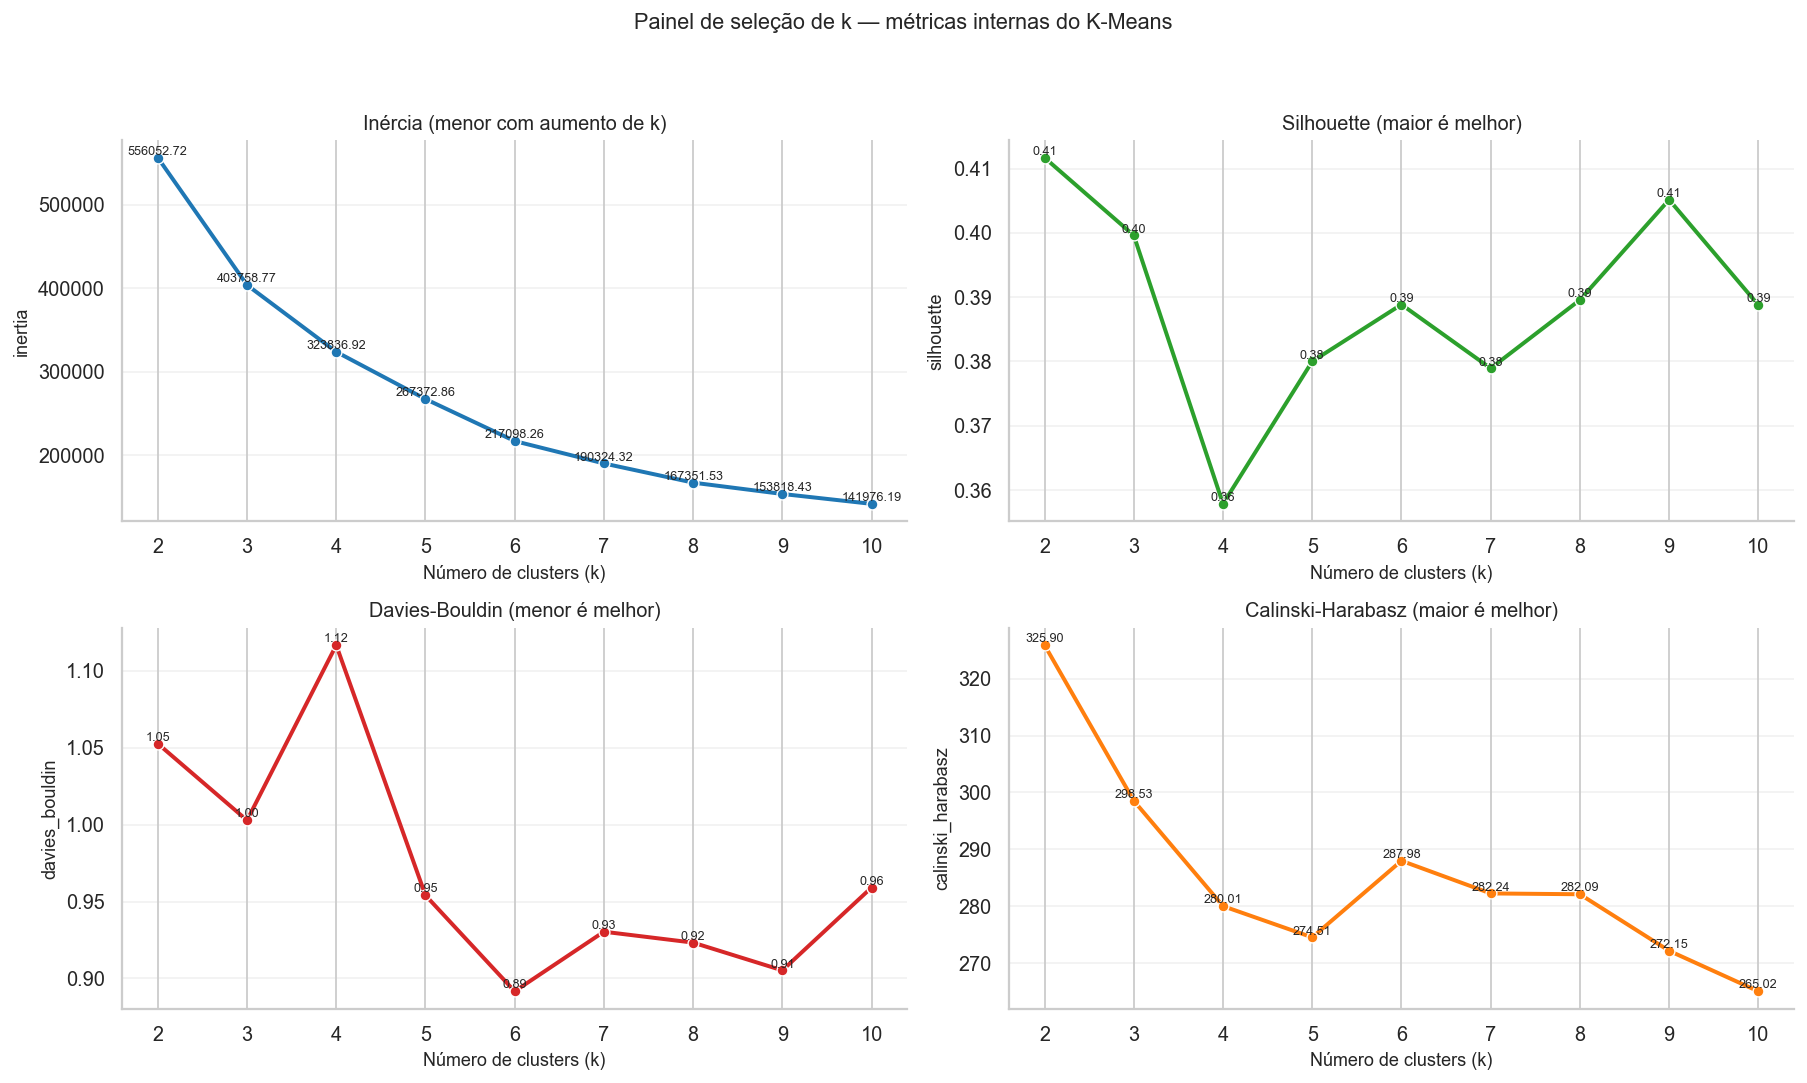

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8.2))
axes = axes.ravel()

plot_specs = [
    ("inertia",           "Inércia",          "menor com aumento de k", BASE_PALETTE[3]),
    ("silhouette",        "Silhouette",        "maior é melhor",         BASE_PALETTE[2]),
    ("davies_bouldin",    "Davies-Bouldin",    "menor é melhor",         BASE_PALETTE[0]),
    ("calinski_harabasz", "Calinski-Harabasz", "maior é melhor",         BASE_PALETTE[1]),
]

for ax, (metric, title, subtitle, color) in zip(axes, plot_specs):
    sns.lineplot(data=selection, x="k", y=metric, marker="o", ax=ax, color=color, linewidth=2.2)
    for _, row in selection.iterrows():
        ax.text(row["k"], row[metric], f"{row[metric]:.2f}", ha="center", va="bottom", fontsize=7)
    ax.set_title(f"{title} ({subtitle})")
    ax.set_xlabel("Número de clusters (k)")
    ax.set_ylabel(metric)
    ax.set_xticks(list(K_VALUES))
    ax.grid(axis="y", alpha=0.25)

plt.suptitle("Painel de seleção de k — métricas internas do K-Means", fontsize=12, y=1.01)
plt.tight_layout(rect=[0, 0, 1, 0.97])
fig.savefig(OUTPUT_DIR / "kmeans_internal_metrics.png", dpi=170, bbox_inches="tight")
plt.show()

## 6. Estabilidade das partições

Além das métricas internas, a escolha de `k` deve considerar estabilidade. Uma solução academicamente mais defensável não deve depender excessivamente da semente inicial nem de pequenas mudanças na amostra.

- Estabilidade por sementes: ARI médio entre partições ajustadas com diferentes `random_state`.
- Estabilidade por bootstrap: ARI médio entre a solução completa e soluções ajustadas em subamostras sem reposição.

O ARI é adequado aqui porque compara partições sem exigir que os rótulos dos clusters tenham o mesmo nome.

In [27]:
stability_rows = []

for k in K_VALUES:
    seed_label_sets = [fit_kmeans(X_model, k, seed=seed)[0] for seed in STABILITY_SEEDS]
    seed_mean, seed_std = mean_pairwise_ari(seed_label_sets)
    boot_mean, boot_std = bootstrap_stability(
        X_model, k, labels_by_k[k],
        n_bootstraps=BOOTSTRAPS,
        fraction=BOOTSTRAP_FRACTION,
        seed=RANDOM_STATE,
    )
    stability_rows.append({
        "k":                            k,
        "seed_stability_ari_mean":      seed_mean,
        "seed_stability_ari_std":       seed_std,
        "bootstrap_stability_ari_mean": boot_mean,
        "bootstrap_stability_ari_std":  boot_std,
    })

stability = pd.DataFrame(stability_rows)
selection = selection.merge(stability, on="k", how="left")
selection["rank_seed_stability"]      = selection["seed_stability_ari_mean"].rank(ascending=False, method="min")
selection["rank_bootstrap_stability"] = selection["bootstrap_stability_ari_mean"].rank(ascending=False, method="min")
selection["consensus_rank_sum"] = selection[
    ["internal_rank_sum", "rank_seed_stability", "rank_bootstrap_stability"]
].sum(axis=1)

eligible = selection[selection["min_cluster_share"] >= MIN_CLUSTER_SHARE].copy()
if eligible.empty:
    eligible = selection.copy()

best_row = eligible.sort_values(
    ["consensus_rank_sum", "internal_rank_sum", "davies_bouldin"],
    ascending=[True, True, True],
).iloc[0]
BEST_K = int(best_row["k"])

selection_ranked = selection.sort_values("consensus_rank_sum").reset_index(drop=True)
display(selection_ranked)
selection_ranked.to_csv(OUTPUT_DIR / "kmeans_selection.csv", index=False, encoding="utf-8-sig")

print(f"k selecionado por critérios internos + estabilidade: {BEST_K}")

,k,inertia,silhouette,davies_bouldin,calinski_harabasz,min_cluster_share,cluster_size_cv,rank_silhouette,rank_davies_bouldin,rank_calinski_harabasz,rank_balance,internal_rank_sum,seed_stability_ari_mean,seed_stability_ari_std,bootstrap_stability_ari_mean,bootstrap_stability_ari_std,rank_seed_stability,rank_bootstrap_stability,consensus_rank_sum
0,2,556052.717297,0.411687,1.052618,325.902943,0.451128,0.097744,1.0,8.0,1.0,1.0,11.0,1.000000,0.000000,0.993312,0.006256,1.0,1.0,13.0
1,3,403758.765211,0.399597,1.002777,298.533644,0.195489,0.426168,3.0,7.0,2.0,2.0,14.0,1.000000,0.000000,0.992291,0.013434,1.0,2.0,17.0
2,6,217098.257162,0.388847,0.891630,287.982444,0.025063,0.528370,5.0,1.0,3.0,4.0,13.0,0.990863,0.011069,0.929460,0.070063,4.0,4.0,21.0
3,8,167351.533179,0.389558,0.923291,282.094433,0.025063,0.416425,4.0,3.0,5.0,4.0,16.0,0.981865,0.023181,0.926581,0.059023,5.0,5.0,26.0
4,9,153818.427795,0.405151,0.905243,272.151469,0.025063,0.424129,2.0,2.0,8.0,4.0,16.0,0.910786,0.058386,0.843097,0.089799,8.0,8.0,32.0
5,4,323836.919120,0.357831,1.116630,280.008752,0.195489,0.144996,9.0,9.0,6.0,2.0,26.0,0.997352,0.007943,0.941091,0.049433,3.0,3.0,32.0
6,7,190324.321939,0.378916,0.930376,282.239624,0.025063,0.439047,8.0,4.0,4.0,4.0,20.0,0.944850,0.032444,0.880442,0.130062,7.0,6.0,33.0
7,5,267372.859368,0.379990,0.954037,274.513340,0.025063,0.481986,7.0,5.0,7.0,4.0,23.0,0.971489,0.034170,0.875344,0.113767,6.0,7.0,36.0
8,10,141976.191491,0.388767,0.959099,265.023475,0.025063,0.536183,6.0,6.0,9.0,4.0,25.0,0.818254,0.072540,0.738084,0.080968,9.0,9.0,43.0


k selecionado por critérios internos + estabilidade: 2


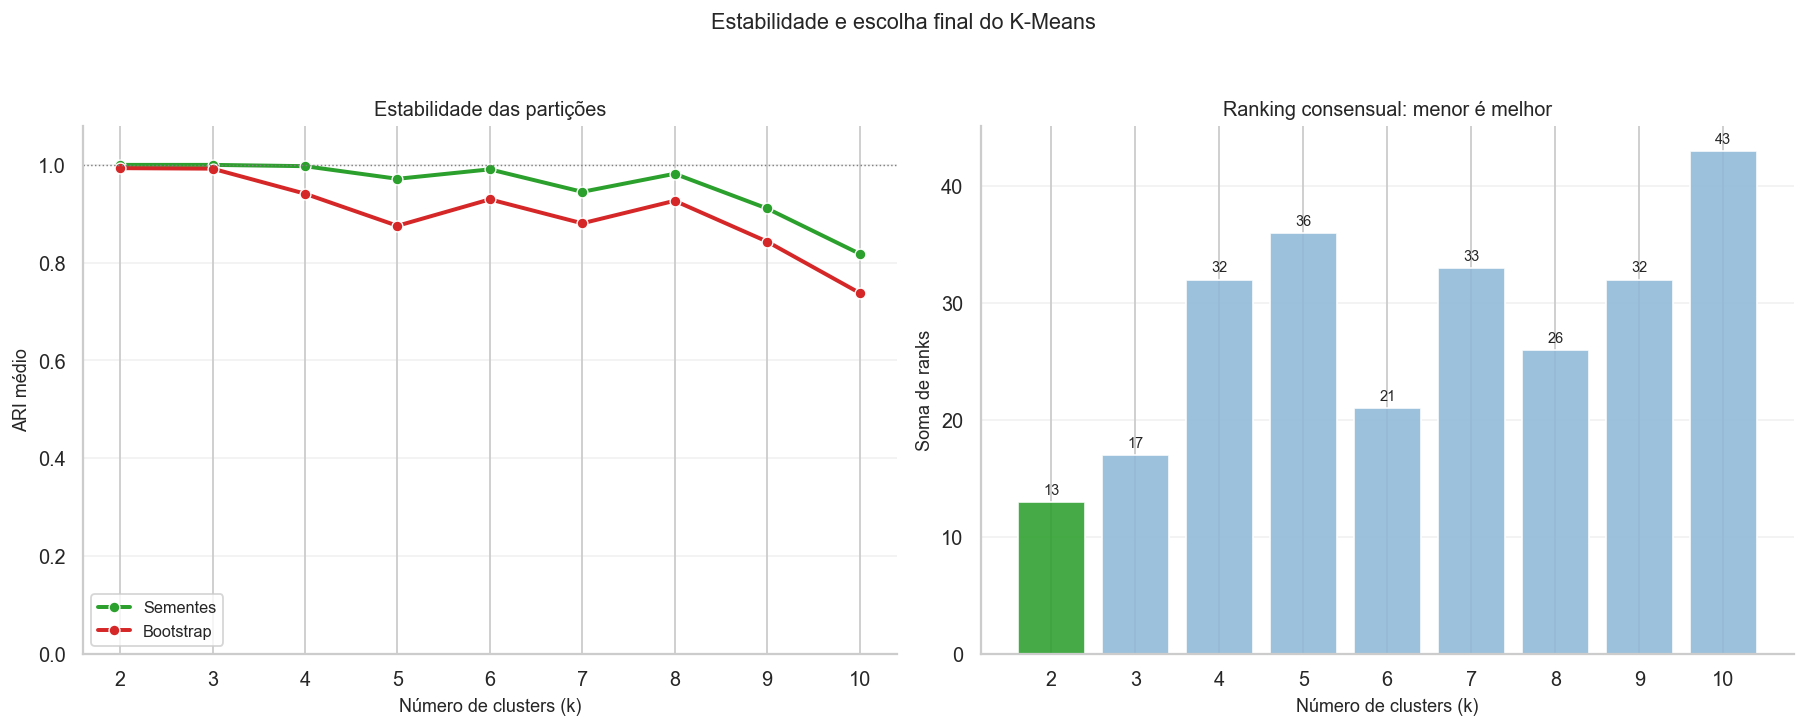

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

sns.lineplot(
    data=selection, x="k", y="seed_stability_ari_mean",
    marker="o", ax=axes[0], label="Sementes",
    color=BASE_PALETTE[2], linewidth=2.2,
)
sns.lineplot(
    data=selection, x="k", y="bootstrap_stability_ari_mean",
    marker="o", ax=axes[0], label="Bootstrap",
    color=BASE_PALETTE[0], linewidth=2.2,
)
axes[0].set_title("Estabilidade das partições")
axes[0].set_xlabel("Número de clusters (k)")
axes[0].set_ylabel("ARI médio")
axes[0].set_xticks(list(K_VALUES))
axes[0].set_ylim(0, 1.08)
axes[0].axhline(1.0, color="gray", linestyle=":", linewidth=0.8)
axes[0].legend(fontsize=9, loc="lower left")
axes[0].grid(axis="y", alpha=0.25)

bar_colors = [BASE_PALETTE[2] if int(k) == BEST_K else "#8fb9d9" for k in selection["k"]]
bars = axes[1].bar(selection["k"].astype(str), selection["consensus_rank_sum"], color=bar_colors, alpha=0.88)
for bar, value in zip(bars, selection["consensus_rank_sum"]):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
        f"{value:.0f}", ha="center", va="bottom", fontsize=8,
    )
axes[1].set_title("Ranking consensual: menor é melhor")
axes[1].set_xlabel("Número de clusters (k)")
axes[1].set_ylabel("Soma de ranks")
axes[1].grid(axis="y", alpha=0.25)

plt.suptitle("Estabilidade e escolha final do K-Means", fontsize=12, y=1.01)
plt.tight_layout(rect=[0, 0, 1, 0.97])
fig.savefig(OUTPUT_DIR / "kmeans_stability_and_rank.png", dpi=170, bbox_inches="tight")
plt.show()

## 6.1. Heatmap das métricas de seleção

O heatmap para tornar as escalas comparáveis, cada métrica é normalizada para 0–100, sempre orientada para que valores maiores indiquem melhor posição relativa.

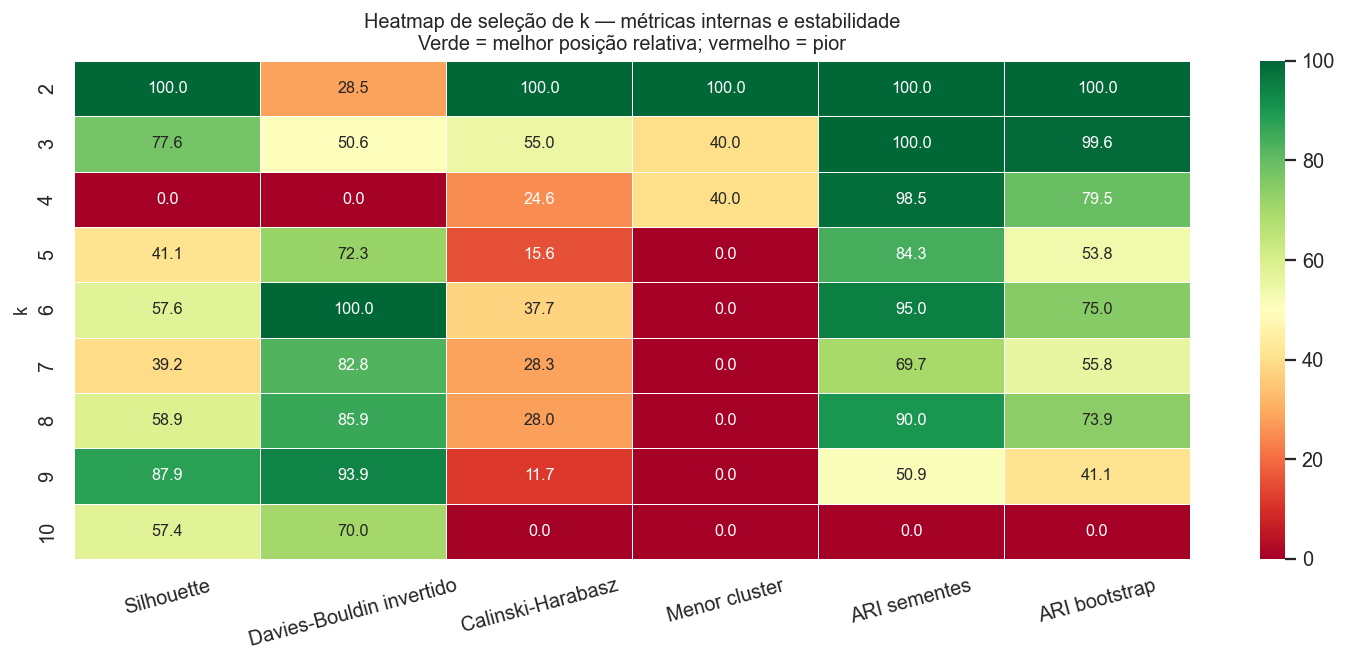

In [29]:
heat_data = selection.set_index("k")[[
    "silhouette",
    "davies_bouldin",
    "calinski_harabasz",
    "min_cluster_share",
    "seed_stability_ari_mean",
    "bootstrap_stability_ari_mean",
]].copy()

oriented = pd.DataFrame(index=heat_data.index)
oriented["Silhouette"]              = heat_data["silhouette"]
oriented["Davies-Bouldin invertido"]= -heat_data["davies_bouldin"]
oriented["Calinski-Harabasz"]       = heat_data["calinski_harabasz"]
oriented["Menor cluster"]           = heat_data["min_cluster_share"]
oriented["ARI sementes"]            = heat_data["seed_stability_ari_mean"]
oriented["ARI bootstrap"]           = heat_data["bootstrap_stability_ari_mean"]

heat_norm = oriented.copy()
for col in heat_norm.columns:
    col_min, col_max = heat_norm[col].min(), heat_norm[col].max()
    if np.isclose(col_min, col_max):
        heat_norm[col] = 100.0
    else:
        heat_norm[col] = 100 * (heat_norm[col] - col_min) / (col_max - col_min)

fig, ax = plt.subplots(figsize=(11.5, 5.2))
sns.heatmap(
    heat_norm,
    annot=True, fmt=".1f", cmap="RdYlGn",
    vmin=0, vmax=100, linewidths=0.5, linecolor="white",
    ax=ax, annot_kws={"fontsize": 9},
)
ax.set_title(
    "Heatmap de seleção de k — métricas internas e estabilidade\n"
    "Verde = melhor posição relativa; vermelho = pior"
)
ax.set_ylabel("k")
ax.set_xlabel("")
ax.tick_params(axis="x", labelrotation=15)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "kmeans_selection_heatmap.png", dpi=170, bbox_inches="tight")
plt.show()

## 6.2. Radar dos critérios não supervisionados

O radar segue o padrão visual do notebook original, mas substitui métricas supervisionadas por critérios de clustering. Os valores estão normalizados entre 0 e 1, sempre orientados para que valores maiores indiquem melhor desempenho relativo.

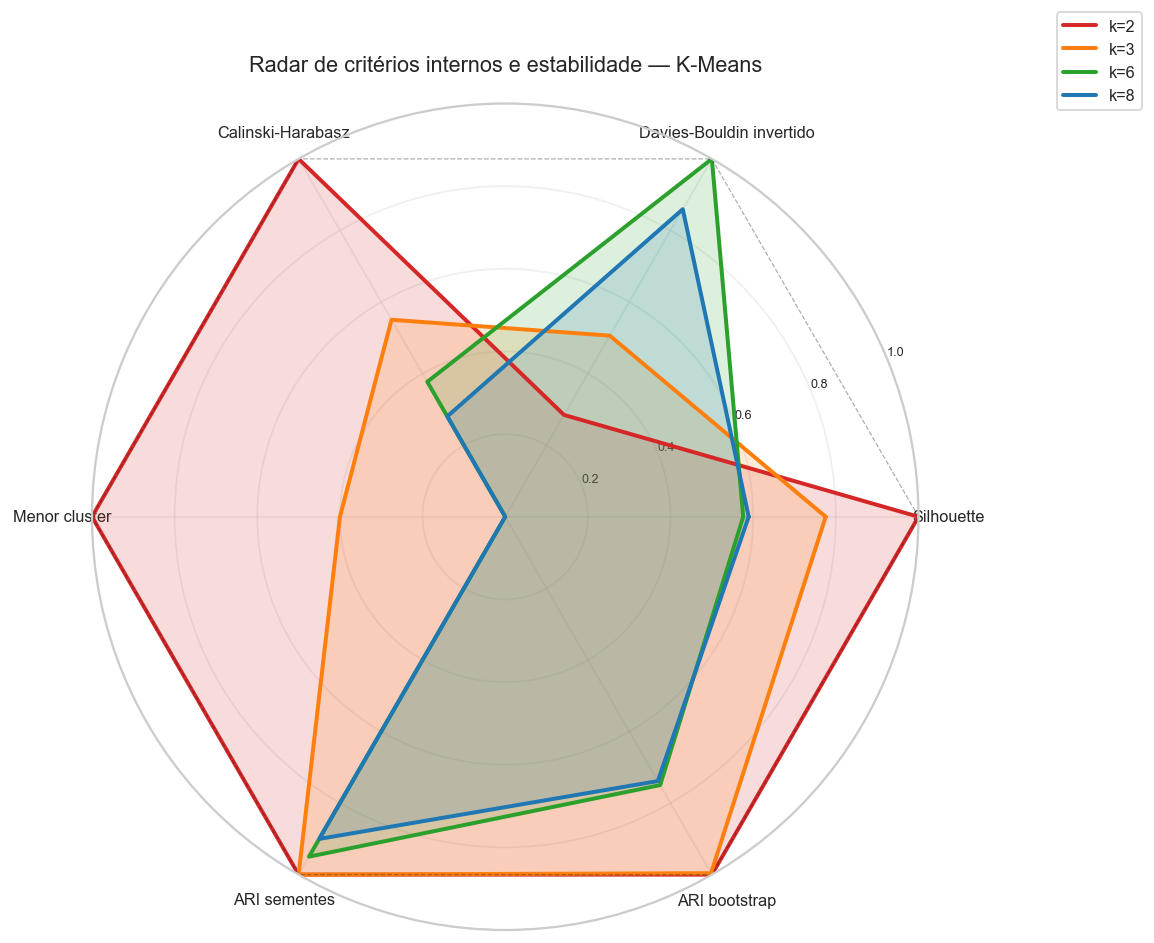

In [30]:
radar_metrics = [
    "Silhouette",
    "Davies-Bouldin invertido",
    "Calinski-Harabasz",
    "Menor cluster",
    "ARI sementes",
    "ARI bootstrap",
]
radar_k_values = selection_ranked["k"].head(min(4, len(selection_ranked))).astype(int).tolist()

angles = np.linspace(0, 2 * np.pi, len(radar_metrics), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8.5, 8), subplot_kw=dict(polar=True))

for idx, k_value in enumerate(radar_k_values):
    values = (heat_norm.loc[k_value, radar_metrics] / 100).to_numpy().tolist()
    values += values[:1]
    color = PALETTE[idx % len(PALETTE)]
    ax.plot(angles, values, color=color, lw=2.2, label=f"k={k_value}")
    ax.fill(angles, values, color=color, alpha=0.16)

ax.plot(angles, [1] * len(angles), "k--", lw=0.7, alpha=0.35)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_metrics, fontsize=9)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "1.0"], fontsize=7)
ax.set_title("Radar de critérios internos e estabilidade — K-Means", fontsize=12, pad=18)
ax.legend(loc="upper right", bbox_to_anchor=(1.28, 1.12), fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "kmeans_radar_internal_stability.png", dpi=170, bbox_inches="tight")
plt.show()

## 7. Modelo final K-Means

Após a seleção de `k`, o modelo final é ajustado uma única vez com a semente definida no protocolo. A coluna `cluster_kmeans` preserva o rótulo original do algoritmo. A coluna `cluster_apresentacao` apenas reordena os grupos para facilitar leitura dos resultados pós-hoc.

In [31]:
final_labels, final_model = fit_kmeans(X_model, BEST_K, seed=RANDOM_STATE)
municipal = municipal.copy()
municipal["cluster_kmeans"] = final_labels

# Ordenação apenas expositiva: do menor para o maior rendimento mediano pós-hoc.
cluster_order = (
    municipal.groupby("cluster_kmeans")[TARGET_COL]
    .median().sort_values().index.tolist()
)
presentation_map = {cluster: i + 1 for i, cluster in enumerate(cluster_order)}
municipal["cluster_apresentacao"] = municipal["cluster_kmeans"].map(presentation_map)

CLUSTER_LABELS = [f"Cluster {i}" for i in range(1, BEST_K + 1)]
cluster_palette = PALETTE[:BEST_K]
CMAP_CLUSTERS   = ListedColormap(cluster_palette)

final_metrics = {
    "k":      BEST_K,
    "inertia": float(final_model.inertia_),
    **compute_internal_metrics(X_model, final_labels),
}
display(pd.DataFrame([final_metrics]))

label_cols = [ID_COL, TARGET_COL, "feature_coverage", "cluster_kmeans", "cluster_apresentacao"]
for optional_col in [NAME_COL, LAT_COL, LON_COL]:
    if optional_col in municipal.columns and optional_col not in label_cols:
        label_cols.insert(1, optional_col)

municipal[label_cols].to_csv(OUTPUT_DIR / "kmeans_final_labels.csv", index=False, encoding="utf-8-sig")

,k,inertia,silhouette,davies_bouldin,calinski_harabasz,min_cluster_share,cluster_size_cv
0,2,556052.717297,0.411687,1.052618,325.902943,0.451128,0.097744


## 8. Perfil dos clusters e validação externa pós-hoc

A tabela abaixo descreve os grupos usando rendimento apenas após o ajuste. O teste de Kruskal-Wallis avalia se a distribuição de rendimento difere entre clusters, mas não transforma o estudo em supervisionado e não estabelece causalidade.

In [32]:
cluster_summary = (
    municipal.groupby("cluster_apresentacao")
    .agg(
        n=(ID_COL, "count"),
        rendimento_media=(TARGET_COL, "mean"),
        rendimento_mediana=(TARGET_COL, "median"),
        rendimento_desvio=(TARGET_COL, "std"),
        rendimento_q25=(TARGET_COL, lambda s: s.quantile(0.25)),
        rendimento_q75=(TARGET_COL, lambda s: s.quantile(0.75)),
        cobertura_media=("feature_coverage", "mean"),
    )
    .reset_index()
)
cluster_summary["participacao_pct"] = 100 * cluster_summary["n"] / len(municipal)
cluster_summary["rendimento_iqr"]   = cluster_summary["rendimento_q75"] - cluster_summary["rendimento_q25"]
cluster_summary = cluster_summary[[
    "cluster_apresentacao", "n", "participacao_pct",
    "rendimento_media", "rendimento_mediana", "rendimento_desvio",
    "rendimento_iqr", "cobertura_media",
]]

display(cluster_summary)
cluster_summary.to_csv(OUTPUT_DIR / "kmeans_cluster_summary.csv", index=False, encoding="utf-8-sig")

reference_quartile = pd.qcut(municipal[TARGET_COL], q=4, labels=False, duplicates="drop").astype(int)
yield_groups = [
    municipal.loc[municipal["cluster_kmeans"] == c, TARGET_COL].to_numpy()
    for c in sorted(municipal["cluster_kmeans"].unique())
]

h_stat, p_value = kruskal(*yield_groups)
epsilon_sq = kruskal_effect_size(h_stat, n_obs=len(municipal), n_groups=BEST_K)

external_validation = pd.DataFrame([{
    "ari_vs_quartis_rendimento": adjusted_rand_score(reference_quartile, final_labels),
    "nmi_vs_quartis_rendimento": normalized_mutual_info_score(reference_quartile, final_labels),
    "ami_vs_quartis_rendimento": adjusted_mutual_info_score(reference_quartile, final_labels),
    "kruskal_h_rendimento":      float(h_stat),
    "kruskal_p_rendimento":      float(p_value),
    "kruskal_epsilon_sq":        epsilon_sq,
}])

display(external_validation)
external_validation.to_csv(OUTPUT_DIR / "kmeans_external_validation_posthoc.csv", index=False, encoding="utf-8-sig")

contingency = pd.crosstab(
    reference_quartile + 1,
    municipal["cluster_apresentacao"],
    rownames=["quartil_rendimento"],
    colnames=["cluster_apresentacao"],
    normalize="index",
) * 100

display(contingency.round(2))

,cluster_apresentacao,n,participacao_pct,rendimento_media,rendimento_mediana,rendimento_desvio,rendimento_iqr,cobertura_media
0,1,219,54.887218,2912.373125,2946.142857,476.664736,542.142857,1.0
1,2,180,45.112782,3231.680159,3452.285714,855.177972,386.107143,1.0


,ari_vs_quartis_rendimento,nmi_vs_quartis_rendimento,ami_vs_quartis_rendimento,kruskal_h_rendimento,kruskal_p_rendimento,kruskal_epsilon_sq
0,0.156765,0.167052,0.164003,97.909538,4.379392e-23,0.244105


cluster_apresentacao,1,2
quartil_rendimento,,
1,80.00,20.00
2,86.00,14.00
3,29.29,70.71
4,24.00,76.00


## 8.1. Apêndice exploratório: curva ROC pós-hoc

Esta curva ROC não é usada para validar nem escolher o K-Means. Ela é mantida apenas como visualização exploratória de associação entre a proximidade ao cluster de maior rendimento mediano e uma referência binária externa de rendimento alto (`Q3` e `Q4`) contra rendimento baixo (`Q1` e `Q2`).

A pontuação usada na curva é derivada da distância ao centroide do cluster pós-hoc de maior rendimento mediano. Portanto, ela não representa probabilidade calibrada nem transforma o estudo em classificação supervisionada.

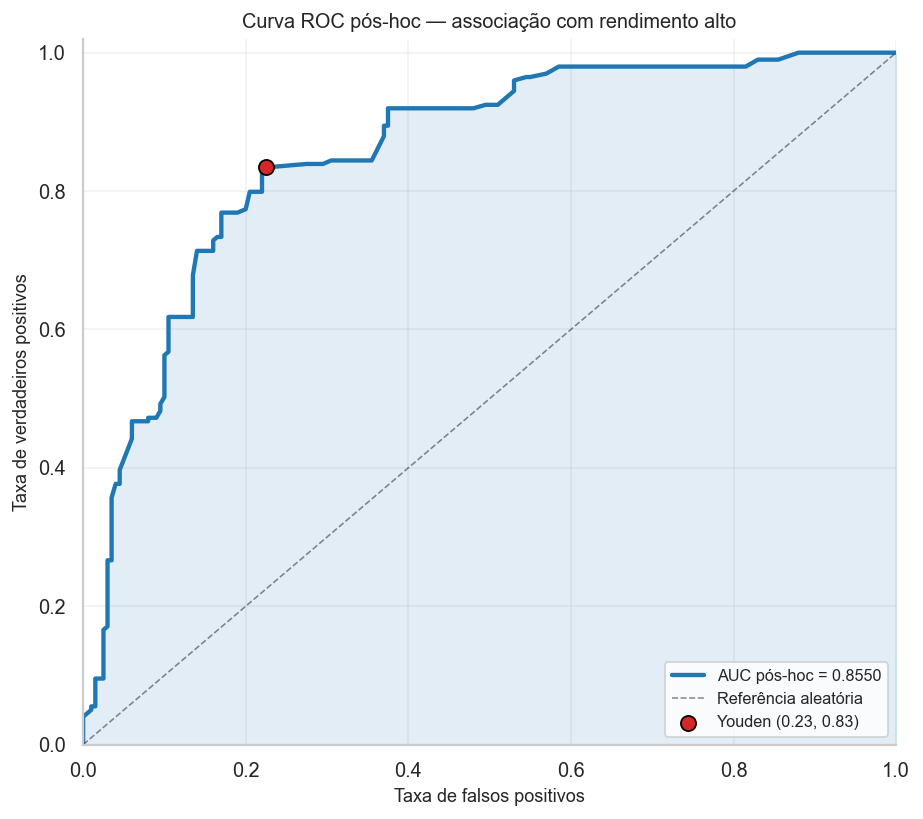

In [33]:
if BEST_K < 2:
    print("ROC pós-hoc não gerada: é necessário pelo menos dois clusters.")
else:
    # Q3-Q4 = rendimento alto; Q1-Q2 = rendimento baixo
    y_binary = (reference_quartile >= 2).astype(int)

    high_cluster_presentation = int(
        cluster_summary.sort_values("rendimento_mediana").iloc[-1]["cluster_apresentacao"]
    )
    inverse_presentation_map = {v: k for k, v in presentation_map.items()}
    high_cluster_raw = inverse_presentation_map[high_cluster_presentation]

    distances = final_model.transform(X_model)
    inverse_distance = 1.0 / (distances + 1e-9)
    posthoc_score = inverse_distance[:, high_cluster_raw] / inverse_distance.sum(axis=1)

    fpr, tpr, thresholds = roc_curve(y_binary, posthoc_score)
    auc_value = auc(fpr, tpr)

    pd.DataFrame({"fpr": fpr, "tpr": tpr, "threshold": thresholds}).to_csv(
        OUTPUT_DIR / "kmeans_roc_posthoc_binary.csv", index=False, encoding="utf-8-sig"
    )

    fig, ax = plt.subplots(figsize=(7.2, 6.4))
    ax.plot(fpr, tpr, color=BASE_PALETTE[3], lw=2.4, label=f"AUC pós-hoc = {auc_value:.4f}")
    ax.fill_between(fpr, tpr, color=BASE_PALETTE[3], alpha=0.13)
    ax.plot([0, 1], [0, 1], "k--", lw=0.9, alpha=0.5, label="Referência aleatória")

    youden_idx = int(np.argmax(tpr - fpr))
    ax.scatter(
        fpr[youden_idx], tpr[youden_idx],
        s=70, color=BASE_PALETTE[0], edgecolors="black", zorder=5,
        label=f"Youden ({fpr[youden_idx]:.2f}, {tpr[youden_idx]:.2f})",
    )

    ax.set_title("Curva ROC pós-hoc — associação com rendimento alto")
    ax.set_xlabel("Taxa de falsos positivos")
    ax.set_ylabel("Taxa de verdadeiros positivos")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=9, loc="lower right")
    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / "kmeans_roc_posthoc_binary.png", dpi=170, bbox_inches="tight")
    plt.show()

## 9. Interpretação climática dos grupos

Como o K-Means foi ajustado no espaço PCA, a interpretação climática é feita pós-hoc pela diferença média padronizada das variáveis originais em cada cluster. Valores positivos indicam que o cluster está acima da média geral naquela variável; valores negativos indicam abaixo da média geral.

In [34]:
global_mean_scaled = X_scaled.mean(axis=0)
profile_rows = []

for cluster in sorted(municipal["cluster_kmeans"].unique()):
    idx = municipal["cluster_kmeans"].to_numpy() == cluster
    cluster_mean = X_scaled[idx].mean(axis=0)
    diff = cluster_mean - global_mean_scaled
    top_idx = np.argsort(np.abs(diff))[::-1][:TOP_PROFILE_FEATURES]

    for rank, feature_idx in enumerate(top_idx, 1):
        profile_rows.append({
            "cluster_kmeans":              int(cluster),
            "cluster_apresentacao":        int(presentation_map[cluster]),
            "rank_abs_diff":               rank,
            "feature":                     climate_cols[feature_idx],
            "media_cluster_padronizada":   float(cluster_mean[feature_idx]),
            "diferenca_vs_media_global":   float(diff[feature_idx]),
            "abs_diferenca":               float(abs(diff[feature_idx])),
        })

feature_profile = pd.DataFrame(profile_rows).sort_values(["cluster_apresentacao", "rank_abs_diff"])
display(feature_profile)
feature_profile.to_csv(OUTPUT_DIR / "kmeans_feature_profile.csv", index=False, encoding="utf-8-sig")

,cluster_kmeans,cluster_apresentacao,rank_abs_diff,feature,media_cluster_padronizada,diferenca_vs_media_global,abs_diferenca
12,1,1,1,TS_MAX_dec29_ano1,0.809285,0.809285,0.809285
13,1,1,2,TS_MAX_dec30_ano1,0.807618,0.807618,0.807618
14,1,1,3,CDD18_3_dec28_ano1,0.802114,0.802114,0.802114
15,1,1,4,TS_dec28_ano1,0.800557,0.800557,0.800557
16,1,1,5,TSURF_dec28_ano1,0.798779,0.798779,0.798779
17,1,1,6,TSOIL1_dec28_ano1,0.797331,0.797331,0.797331
18,1,1,7,TS_MAX_dec11_ano2,0.795620,0.795620,0.795620
19,1,1,8,TSURF_dec30_ano1,0.795407,0.795407,0.795407
20,1,1,9,TSOIL2_dec28_ano1,0.794830,0.794830,0.794830
21,1,1,10,TSOIL1_dec30_ano1,0.793825,0.793825,0.793825


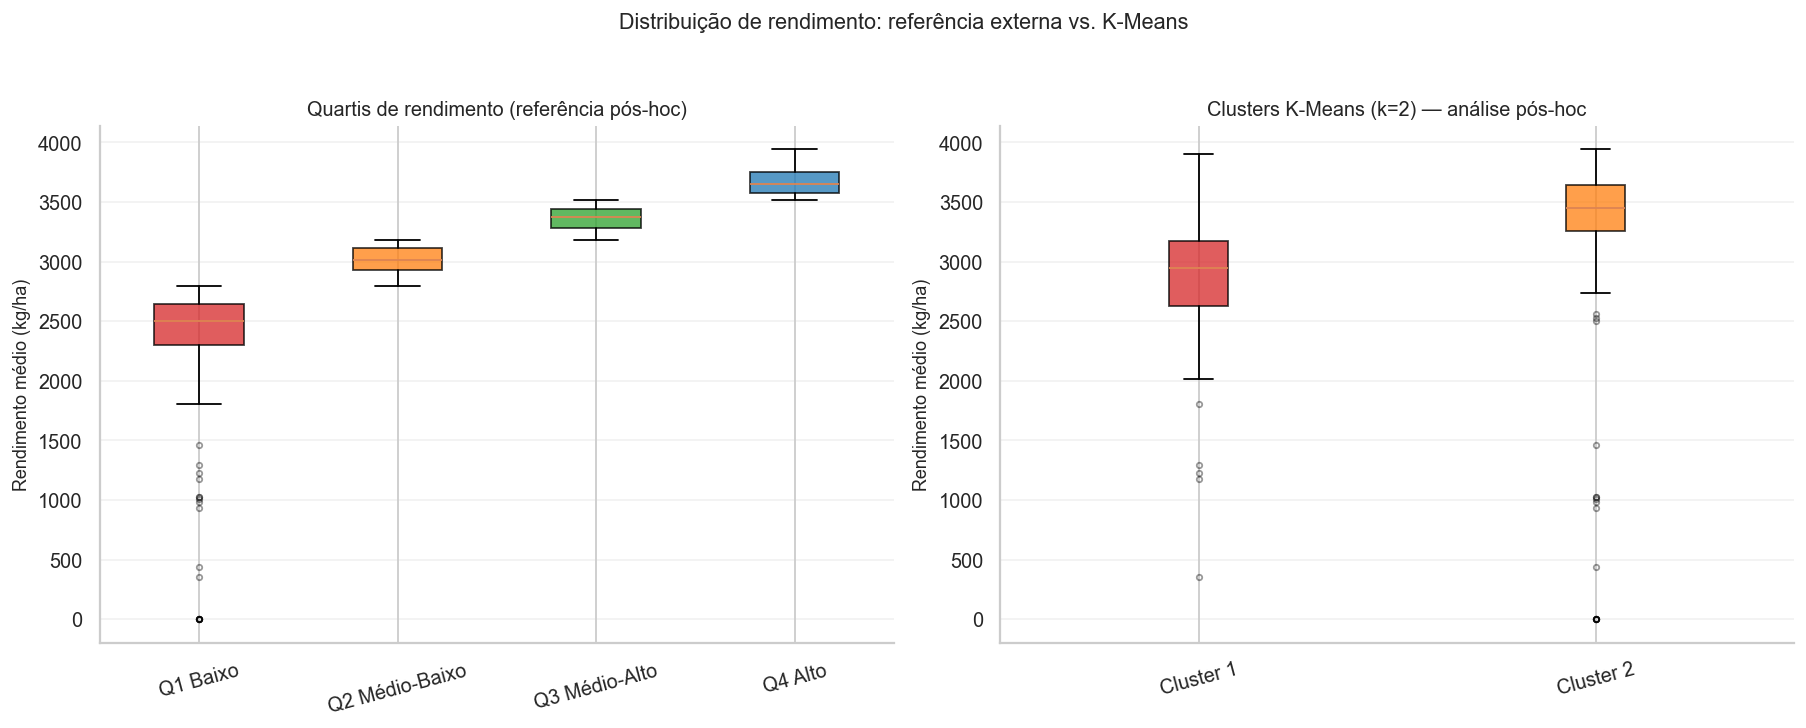

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Boxplot: quartis de rendimento como referência externa
quartile_palette = BASE_PALETTE[:4]
quartile_labels  = ["Q1 Baixo", "Q2 Médio-Baixo", "Q3 Médio-Alto", "Q4 Alto"]
reference_plot = municipal.copy()
reference_plot["quartil_rendimento"] = reference_quartile + 1

data_reference = [
    reference_plot.loc[reference_plot["quartil_rendimento"] == i, TARGET_COL].values
    for i in range(1, 5)
]
bp1 = axes[0].boxplot(
    data_reference,
    labels=quartile_labels,
    patch_artist=True,
    showfliers=True,
    flierprops=dict(marker="o", markersize=3, alpha=0.4),
)
for patch, color in zip(bp1["boxes"], quartile_palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
axes[0].set_ylabel("Rendimento médio (kg/ha)")
axes[0].set_title("Quartis de rendimento (referência pós-hoc)")
axes[0].tick_params(axis="x", labelrotation=15)
axes[0].grid(axis="y", alpha=0.25)

# Boxplot: clusters K-Means
data_clusters = [
    municipal.loc[municipal["cluster_apresentacao"] == i, TARGET_COL].values
    for i in range(1, BEST_K + 1)
]
bp2 = axes[1].boxplot(
    data_clusters,
    labels=CLUSTER_LABELS,
    patch_artist=True,
    showfliers=True,
    flierprops=dict(marker="o", markersize=3, alpha=0.4),
)
for patch, color in zip(bp2["boxes"], cluster_palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
axes[1].set_ylabel("Rendimento médio (kg/ha)")
axes[1].set_title(f"Clusters K-Means (k={BEST_K}) — análise pós-hoc")
axes[1].tick_params(axis="x", labelrotation=15)
axes[1].grid(axis="y", alpha=0.25)

plt.suptitle("Distribuição de rendimento: referência externa vs. K-Means", fontsize=12, y=1.01)
plt.tight_layout(rect=[0, 0, 1, 0.97])
fig.savefig(OUTPUT_DIR / "kmeans_yield_boxplots_original_style.png", dpi=170, bbox_inches="tight")
plt.show()

## 9.1. Visualização dos clusters no espaço PCA

Esta figura mostra os clusters no espaço das duas primeiras componentes principais. Ela é descritiva: a seleção formal do modelo permanece baseada nas métricas internas e na estabilidade.

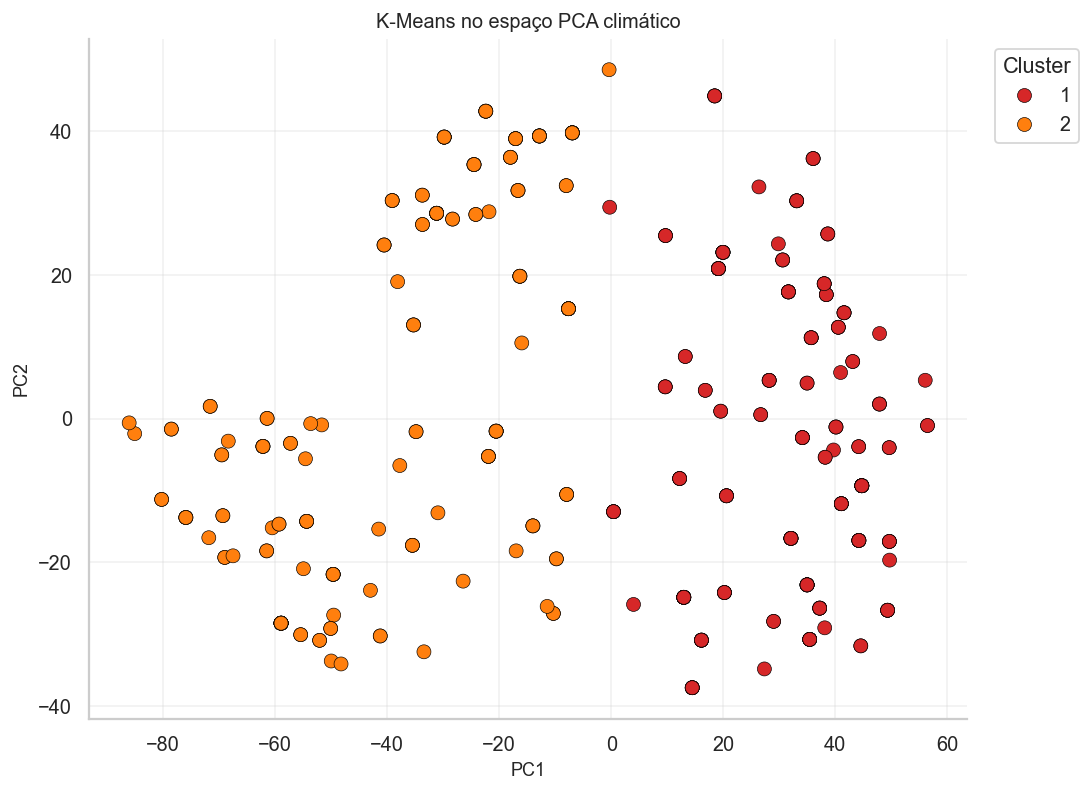

In [36]:
plot_df = pd.DataFrame({
    "PC1":                   X_model[:, 0],
    "PC2":                   X_model[:, 1],
    "cluster_apresentacao":  municipal["cluster_apresentacao"].astype(str),
    TARGET_COL:              municipal[TARGET_COL].to_numpy(),
})

fig, ax = plt.subplots(figsize=(8.5, 6.2))
sns.scatterplot(
    data=plot_df, x="PC1", y="PC2",
    hue="cluster_apresentacao", palette=cluster_palette,
    s=60, edgecolor="black", linewidth=0.35, ax=ax,
)
ax.set_title("K-Means no espaço PCA climático")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(alpha=0.25)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "kmeans_pca_scatter_original_style.png", dpi=170, bbox_inches="tight")
plt.show()

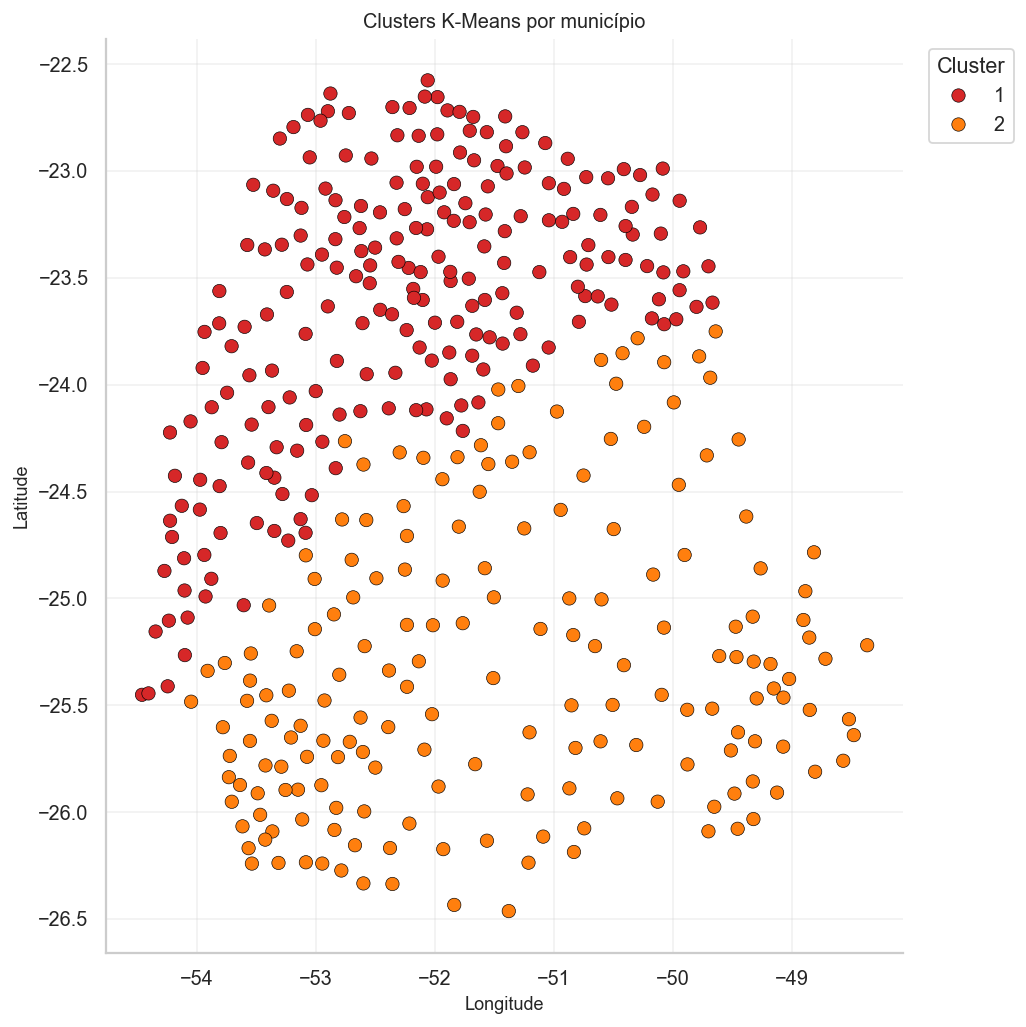

In [37]:
if LAT_COL in municipal.columns and LON_COL in municipal.columns:
    fig, ax = plt.subplots(figsize=(8, 8))
    sns.scatterplot(
        data=municipal, x=LON_COL, y=LAT_COL,
        hue=municipal["cluster_apresentacao"].astype(str),
        palette=cluster_palette,
        s=55, edgecolor="black", linewidth=0.35, ax=ax,
    )
    ax.set_title("Clusters K-Means por município")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
    ax.grid(alpha=0.25)
    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / "kmeans_spatial_scatter.png", dpi=170, bbox_inches="tight")
    plt.show()
else:
    print("Colunas de latitude/longitude ausentes; mapa de dispersão não foi gerado.")

## 9.2. Interpolação espacial com RBF, clipping no Paraná e comparação por limiares

Esta etapa recupera o padrão cartográfico do `unsupervised.ipynb`: usa o contorno do Paraná do `geobr`, aplica clipping espacial e gera superfícies interpoladas por RBF.

Além do mapa de clusters, são gerados dois mapas comparativos pós-hoc: municípios acima da mediana do rendimento e municípios acima da média do rendimento. A comparação com o K-Means usa o cluster de maior rendimento mediano como referência binária exploratória, sem transformar o modelo em classificação supervisionada.

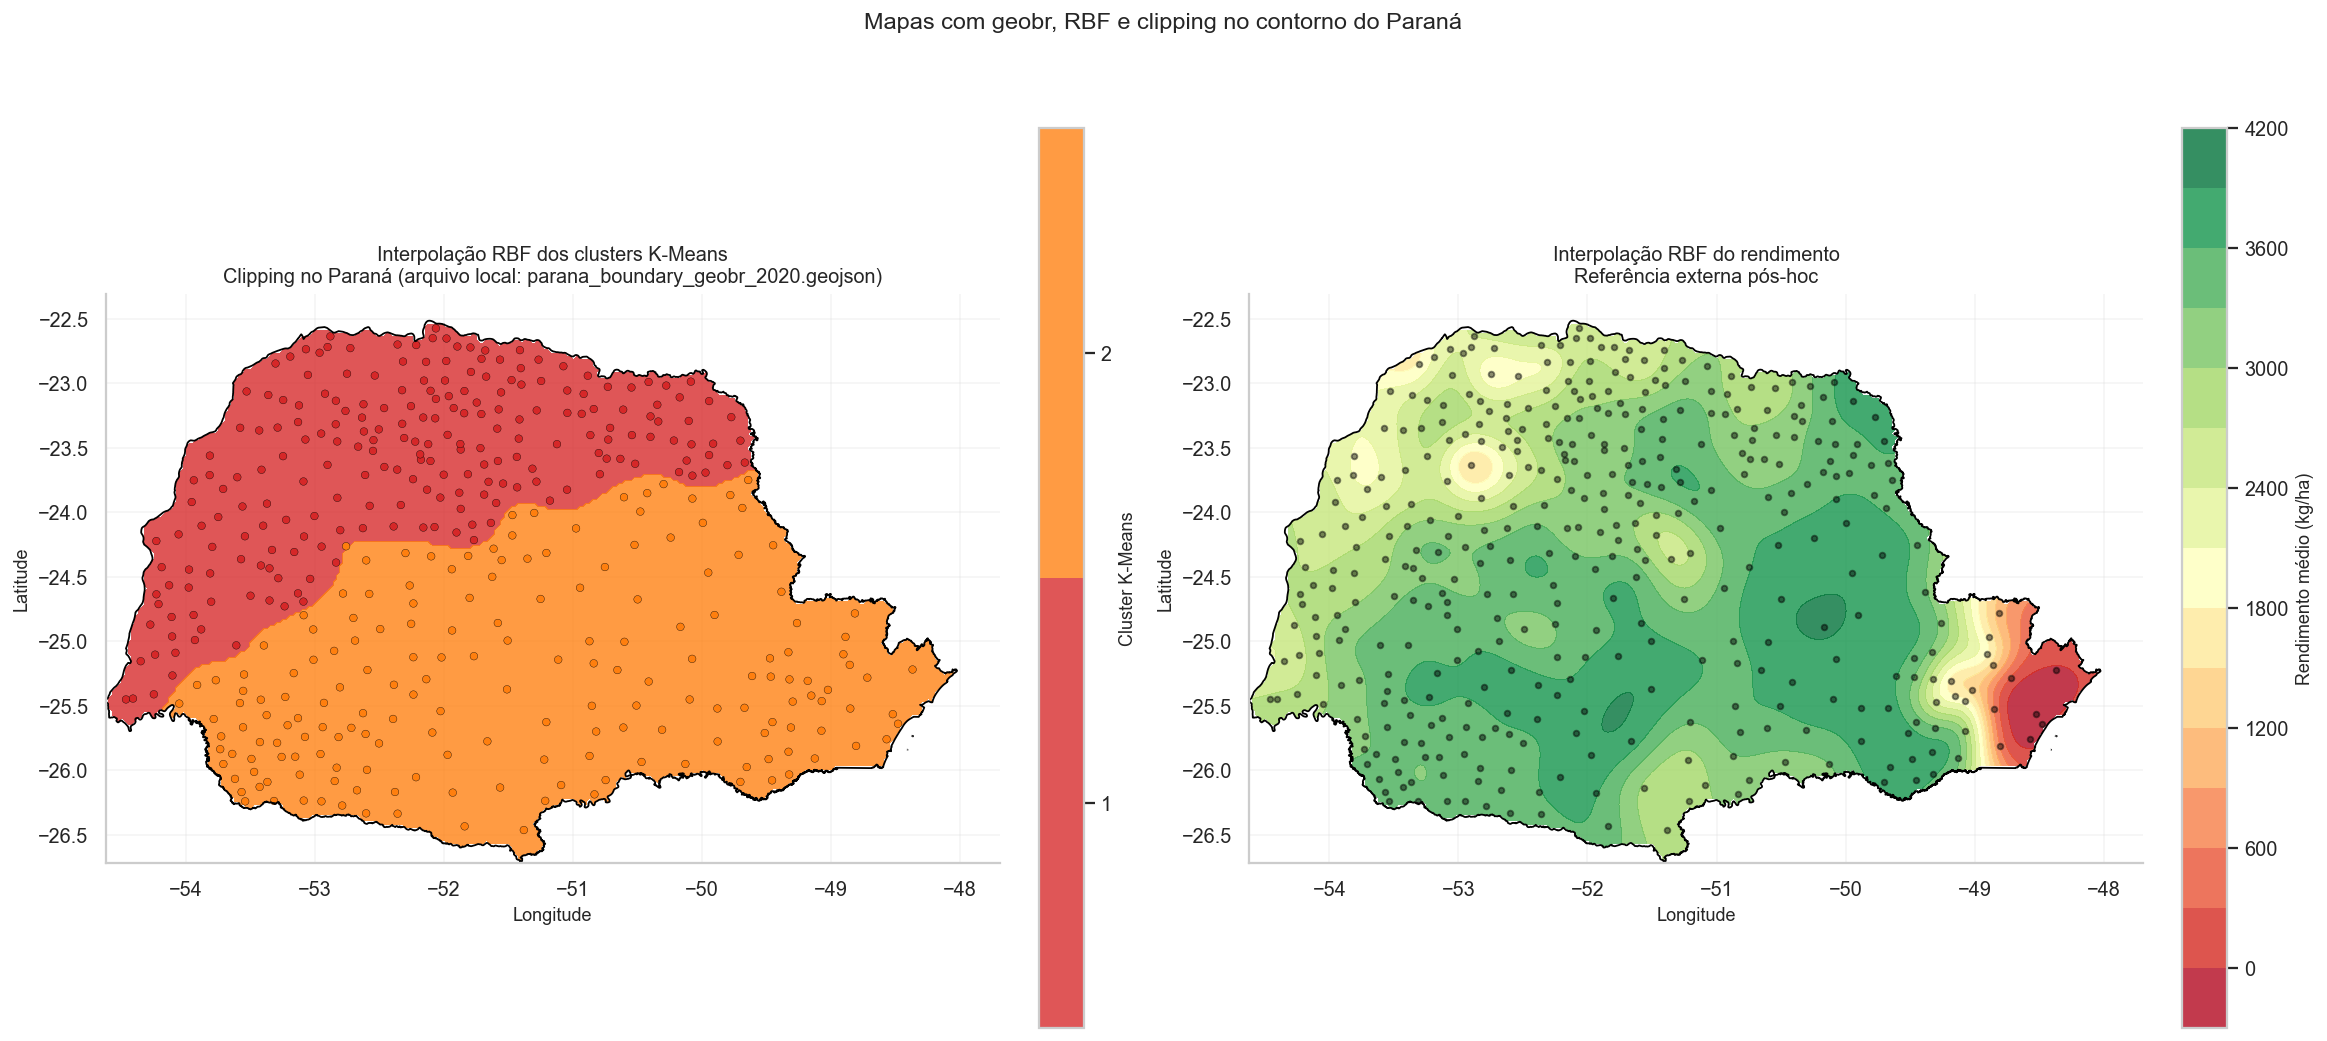

,comparacao,limiar_kg_ha,n_acima_limiar,n_cluster_kmeans_maior_mediana,concordancia_pontos_pct,ari_binario_posthoc
0,Rendimento acima da mediana,3180.000000,199,180,78.195489,0.316293
1,Rendimento acima da média,3056.421411,239,180,71.679198,0.185743


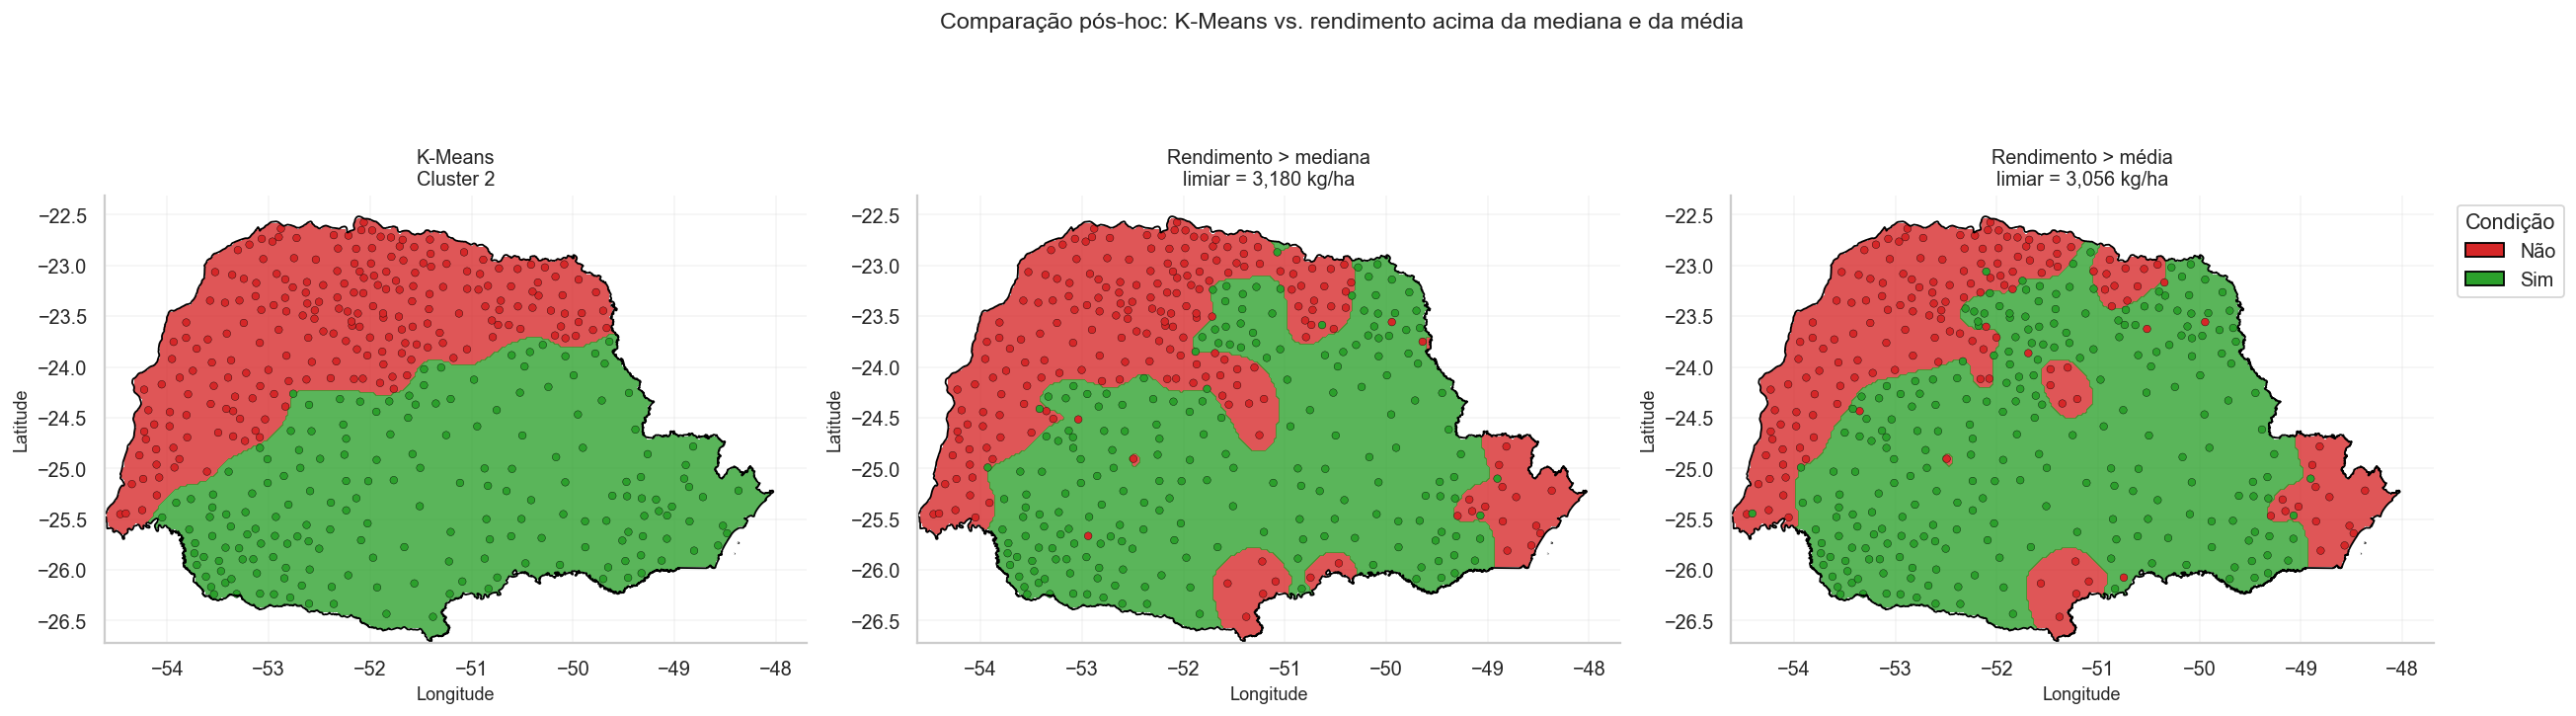

In [38]:
try:
    import geopandas as gpd
    import geobr
    from matplotlib.colors import BoundaryNorm, ListedColormap
    from matplotlib.patches import Patch
    from scipy.interpolate import Rbf
    from shapely.geometry import Point

    try:
        from shapely import contains_xy
    except ImportError:
        contains_xy = None

    if PARANA_BOUNDARY_PATH.exists():
        pr_boundary  = gpd.read_file(PARANA_BOUNDARY_PATH).to_crs("EPSG:4326")
        boundary_source = f"arquivo local: {PARANA_BOUNDARY_PATH.name}"
    else:
        pr_boundary  = geobr.read_state(code_state="PR", year=2020).to_crs("EPSG:4326")
        boundary_source = "geobr.read_state(code_state='PR', year=2020)"

    if LAT_COL not in municipal.columns or LON_COL not in municipal.columns:
        raise KeyError("Colunas de latitude/longitude ausentes.")

    coords_valid = municipal.dropna(subset=[LAT_COL, LON_COL, TARGET_COL, "cluster_apresentacao"]).copy()
    geometry = [Point(xy) for xy in zip(coords_valid[LON_COL], coords_valid[LAT_COL])]
    gdf = gpd.GeoDataFrame(coords_valid, geometry=geometry, crs="EPSG:4326")
    gdf_clipped = gpd.clip(gdf, pr_boundary)

    if len(gdf_clipped) <= 3:
        raise ValueError("Pontos insuficientes dentro do contorno do Paraná para interpolação RBF.")

    minx, miny, maxx, maxy = pr_boundary.total_bounds
    resolution = 0.025
    xx, yy = np.meshgrid(
        np.arange(minx, maxx, resolution),
        np.arange(miny, maxy, resolution),
    )

    # union_all() introduzido no Shapely 2.0; unary_union funciona em ambas as versões
    try:
        boundary_geom = pr_boundary.geometry.union_all()
    except AttributeError:
        boundary_geom = pr_boundary.geometry.unary_union

    if contains_xy is not None:
        inside_mask = contains_xy(boundary_geom, xx, yy)
    else:
        inside_mask = np.array(
            [boundary_geom.contains(Point(x, y)) for x, y in zip(xx.ravel(), yy.ravel())]
        ).reshape(xx.shape)

    x_pts   = gdf_clipped.geometry.x.to_numpy()
    y_pts   = gdf_clipped.geometry.y.to_numpy()
    z_cluster = gdf_clipped["cluster_apresentacao"].astype(float).to_numpy()
    z_yield   = gdf_clipped[TARGET_COL].astype(float).to_numpy()

    rbf_cluster = Rbf(x_pts, y_pts, z_cluster, function="multiquadric", smooth=0.15)
    rbf_yield   = Rbf(x_pts, y_pts, z_yield,   function="multiquadric", smooth=0.20)

    zz_cluster = np.clip(np.rint(rbf_cluster(xx, yy)), 1, BEST_K)
    zz_cluster[~inside_mask] = np.nan

    zz_yield = rbf_yield(xx, yy)
    zz_yield[~inside_mask] = np.nan

    fig, axes = plt.subplots(1, 2, figsize=(18, 8))

    levels_cluster = np.arange(0.5, BEST_K + 1.5, 1)
    # colors deve ter exatamente len(levels)-1 entradas
    _n_intervals = len(levels_cluster) - 1
    cluster_map = axes[0].contourf(
        xx, yy, zz_cluster,
        levels=levels_cluster, colors=cluster_palette[:_n_intervals], alpha=0.78,
    )
    pr_boundary.boundary.plot(ax=axes[0], color="black", linewidth=1.0)
    axes[0].scatter(x_pts, y_pts, c=z_cluster, cmap=CMAP_CLUSTERS, s=18, edgecolor="black", linewidth=0.2)
    cbar0 = fig.colorbar(cluster_map, ax=axes[0], fraction=0.046, pad=0.04, ticks=list(range(1, BEST_K + 1)))
    cbar0.set_label("Cluster K-Means")
    axes[0].set_title(f"Interpolação RBF dos clusters K-Means\nClipping no Paraná ({boundary_source})")
    axes[0].set_xlabel("Longitude")
    axes[0].set_ylabel("Latitude")

    yield_map = axes[1].contourf(xx, yy, zz_yield, levels=15, cmap="RdYlGn", alpha=0.82)
    pr_boundary.boundary.plot(ax=axes[1], color="black", linewidth=1.0)
    axes[1].scatter(x_pts, y_pts, c="black", s=10, alpha=0.45)
    cbar1 = fig.colorbar(yield_map, ax=axes[1], fraction=0.046, pad=0.04)
    cbar1.set_label("Rendimento médio (kg/ha)")
    axes[1].set_title("Interpolação RBF do rendimento\nReferência externa pós-hoc")
    axes[1].set_xlabel("Longitude")
    axes[1].set_ylabel("Latitude")

    for ax in axes:
        ax.set_aspect("equal", adjustable="box")
        ax.grid(alpha=0.18)

    plt.suptitle("Mapas com geobr, RBF e clipping no contorno do Paraná", fontsize=13, y=1.01)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    fig.savefig(OUTPUT_DIR / "kmeans_geobr_rbf_parana.png", dpi=180, bbox_inches="tight")
    plt.show()

    # Comparação pós-hoc: K-Means vs. acima da mediana/média
    high_cluster_presentation = int(
        cluster_summary.sort_values("rendimento_mediana").iloc[-1]["cluster_apresentacao"]
    )
    yield_median = float(gdf_clipped[TARGET_COL].median())
    yield_mean   = float(gdf_clipped[TARGET_COL].mean())

    gdf_clipped = gdf_clipped.copy()
    gdf_clipped["kmeans_maior_mediana"] = (gdf_clipped["cluster_apresentacao"] == high_cluster_presentation).astype(int)
    gdf_clipped["acima_mediana"]        = (gdf_clipped[TARGET_COL] > yield_median).astype(int)
    gdf_clipped["acima_media"]          = (gdf_clipped[TARGET_COL] > yield_mean).astype(int)

    comparison_rows = []
    for col, label, threshold in [
        ("acima_mediana", "Rendimento acima da mediana", yield_median),
        ("acima_media",   "Rendimento acima da média",   yield_mean),
    ]:
        kmeans_binary    = gdf_clipped["kmeans_maior_mediana"].to_numpy()
        reference_binary = gdf_clipped[col].to_numpy()
        comparison_rows.append({
            "comparacao":                        label,
            "limiar_kg_ha":                      threshold,
            "n_acima_limiar":                    int(reference_binary.sum()),
            "n_cluster_kmeans_maior_mediana":    int(kmeans_binary.sum()),
            "concordancia_pontos_pct":           float((kmeans_binary == reference_binary).mean()) * 100,
            "ari_binario_posthoc":               float(adjusted_rand_score(kmeans_binary, reference_binary)),
        })
        pd.crosstab(
            gdf_clipped["kmeans_maior_mediana"],
            gdf_clipped[col],
            rownames=["kmeans_cluster_maior_mediana"],
            colnames=[col],
        ).to_csv(OUTPUT_DIR / f"kmeans_crosstab_{col}.csv", encoding="utf-8-sig")

    threshold_comparison = pd.DataFrame(comparison_rows)
    display(threshold_comparison)
    threshold_comparison.to_csv(
        OUTPUT_DIR / "kmeans_threshold_comparison_posthoc.csv",
        index=False, encoding="utf-8-sig",
    )

    binary_specs = [
        ("kmeans_maior_mediana", f"K-Means\nCluster {high_cluster_presentation}", "kmeans_binary_high_cluster"),
        ("acima_mediana",        f"Rendimento > mediana\nlimiar = {yield_median:,.0f} kg/ha",     "yield_above_median"),
        ("acima_media",          f"Rendimento > média\nlimiar = {yield_mean:,.0f} kg/ha",         "yield_above_mean"),
    ]

    binary_cmap   = ListedColormap([BASE_PALETTE[0], BASE_PALETTE[2]])
    binary_norm   = BoundaryNorm([-0.5, 0.5, 1.5], binary_cmap.N)
    binary_legend = [
        Patch(facecolor=BASE_PALETTE[0], edgecolor="black", label="Não"),
        Patch(facecolor=BASE_PALETTE[2], edgecolor="black", label="Sim"),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(21, 5.8))
    for ax, (col, title, _) in zip(axes, binary_specs):
        z_binary = gdf_clipped[col].astype(float).to_numpy()
        zz_binary_score = Rbf(x_pts, y_pts, z_binary, function="multiquadric", smooth=0.15)(xx, yy)
        zz_binary = (zz_binary_score >= 0.5).astype(float)
        zz_binary[~inside_mask] = np.nan

        ax.contourf(xx, yy, zz_binary, levels=[-0.5, 0.5, 1.5],
                    cmap=binary_cmap, norm=binary_norm, alpha=0.78)
        pr_boundary.boundary.plot(ax=ax, color="black", linewidth=1.0)

        # Usar apenas pontos sem NaN (z_binary dos pontos originais nunca é NaN)
        _valid = np.isfinite(z_binary)
        ax.scatter(x_pts[_valid], y_pts[_valid], c=z_binary[_valid],
                   cmap=binary_cmap, norm=binary_norm, s=18, edgecolor="black", linewidth=0.2)
        ax.set_title(title)
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        ax.set_aspect("equal", adjustable="box")
        ax.grid(alpha=0.18)

    axes[-1].legend(handles=binary_legend, title="Condição", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.suptitle("Comparação pós-hoc: K-Means vs. rendimento acima da mediana e da média",
                 fontsize=13, y=0.98)
    plt.tight_layout(rect=[0, 0, 0.96, 0.92])
    fig.savefig(OUTPUT_DIR / "kmeans_geobr_rbf_threshold_comparison.png", dpi=180, bbox_inches="tight")
    plt.show()

except Exception as exc:
    print("Mapa com geobr/RBF não foi gerado neste ambiente.")
    print(f"Motivo: {type(exc).__name__}: {exc}")

## 10. Síntese acadêmica gerada pelo notebook

A célula final registra uma nota metodológica curta com os principais resultados e limitações. Ela também salva a nota em Markdown para uso em relatório.

In [39]:
best     = selection.loc[selection["k"] == BEST_K].iloc[0]
external = external_validation.iloc[0]

method_note = f"""# Nota metodológica — K-Means não supervisionado

Objetivo:
- Agrupar municípios por padrões climáticos decendiais, sem usar rendimento, produção, área, coordenadas ou identificadores no ajuste.

Algoritmo:
- K-Means foi o único algoritmo de clustering utilizado.
- A variação de k entre {min(K_VALUES)} e {max(K_VALUES)} foi tratada como seleção de hiperparâmetro, não como comparação de algoritmos.

Pré-processamento:
- Agregação por município usando média histórica.
- Imputação por mediana nas variáveis climáticas.
- Padronização z-score.
- PCA com {n_components} componentes, explicando {cumulative_variance[n_components - 1]:.2%} da variância.

Escolha de k:
- k selecionado: {BEST_K}.
- Silhouette: {best['silhouette']:.4f}.
- Davies-Bouldin: {best['davies_bouldin']:.4f}.
- Calinski-Harabasz: {best['calinski_harabasz']:.2f}.
- Menor participação de cluster: {best['min_cluster_share']:.2%}.
- Estabilidade por sementes, ARI médio: {best['seed_stability_ari_mean']:.4f}.
- Estabilidade por bootstrap, ARI médio: {best['bootstrap_stability_ari_mean']:.4f}.

Validação externa pós-hoc:
- Rendimento foi usado apenas depois do clustering.
- ARI contra quartis de rendimento: {external['ari_vs_quartis_rendimento']:.4f}.
- NMI contra quartis de rendimento: {external['nmi_vs_quartis_rendimento']:.4f}.
- Kruskal-Wallis p-valor: {external['kruskal_p_rendimento']:.6g}.
- Epsilon squared: {external['kruskal_epsilon_sq']:.4f}.

Interpretação:
- Os clusters descrevem estrutura climática nos municípios.
- Associação com rendimento deve ser interpretada como evidência exploratória, não causal.
- Fatores não climáticos, como solo, manejo, cultivar, tecnologia, pragas e mercado, podem influenciar o rendimento.
"""

print(method_note)
(OUTPUT_DIR / "nota_metodologica_kmeans.md").write_text(method_note, encoding="utf-8")

# Nota metodológica — K-Means não supervisionado

Objetivo:
- Agrupar municípios por padrões climáticos decendiais, sem usar rendimento, produção, área, coordenadas ou identificadores no ajuste.

Algoritmo:
- K-Means foi o único algoritmo de clustering utilizado.
- A variação de k entre 2 e 10 foi tratada como seleção de hiperparâmetro, não como comparação de algoritmos.

Pré-processamento:
- Agregação por município usando média histórica.
- Imputação por mediana nas variáveis climáticas.
- Padronização z-score.
- PCA com 6 componentes, explicando 87.11% da variância.

Escolha de k:
- k selecionado: 2.
- Silhouette: 0.4117.
- Davies-Bouldin: 1.0526.
- Calinski-Harabasz: 325.90.
- Menor participação de cluster: 45.11%.
- Estabilidade por sementes, ARI médio: 1.0000.
- Estabilidade por bootstrap, ARI médio: 0.9933.

Validação externa pós-hoc:
- Rendimento foi usado apenas depois do clustering.
- ARI contra quartis de rendimento: 0.1568.
- NMI contra quartis de rendimento: 0.1671.
- Krusk

1343